<a href="https://colab.research.google.com/github/hend-22/-IT326-Project/blob/main/Reports/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/hend-22/-IT326-Project/main/Dataset/Raw_Dataset.csv"
df = pd.read_csv(url)

df.shape

(10000, 16)

#**Five-Number Summary**

####The five-number summary is used to describe the distribution of the numerical attributes using the minimum, first quartile (Q1), median, third quartile (Q3), and maximum values.

In [4]:
df.describe().loc[['min', '25%', '50%', '75%', 'max']]


,Age,BMI,Caffeine_Intake_mg,Water_Intake_liters,Screen_Time_Hours,Daily_Steps,Calories_Burned,Resting_Heart_Rate,Daily_Sleep_Hours,Deep_Sleep_Hours,Sleep_Quality_Score
min,18.0,17.5,0.0,0.5,2.0,1000.00,491.0,50.0,3.5,0.7,1.0
25%,31.0,22.3,100.0,2.0,5.3,4919.50,1354.0,61.0,6.3,1.4,3.5
50%,43.0,25.1,201.0,2.5,7.1,7396.50,1561.0,67.0,7.0,1.7,4.2
75%,56.0,27.8,303.0,3.0,8.7,10119.25,1786.0,73.0,7.6,2.1,4.8
max,69.0,38.0,730.0,5.0,14.0,23451.00,2901.0,95.0,10.9,3.4,7.5


#**Statistical Summary**

####The statistical summary provides descriptive statistics for the numerical attributes, including count, mean, standard deviation, minimum, quartiles, and maximum values.

In [5]:
df.describe()

,Age,BMI,Caffeine_Intake_mg,Water_Intake_liters,Screen_Time_Hours,Daily_Steps,Calories_Burned,Resting_Heart_Rate,Daily_Sleep_Hours,Deep_Sleep_Hours,Sleep_Quality_Score
count,10000.000000,9790.000000,9794.000000,10000.000000,10000.000000,10000.000000,10000.000000,9781.000000,9810.000000,10000.000000,10000.000000
mean,43.539400,25.087406,207.365224,2.502550,7.060990,7963.857000,1573.986300,66.944177,6.957951,1.750610,4.170080
std,14.911636,3.905276,137.681368,0.802058,2.443689,4021.490815,320.153851,8.450527,0.907726,0.467773,0.914011
min,18.000000,17.500000,0.000000,0.500000,2.000000,1000.000000,491.000000,50.000000,3.500000,0.700000,1.000000
25%,31.000000,22.300000,100.000000,2.000000,5.300000,4919.500000,1354.000000,61.000000,6.300000,1.400000,3.500000
50%,43.000000,25.100000,201.000000,2.500000,7.100000,7396.500000,1561.000000,67.000000,7.000000,1.700000,4.200000
75%,56.000000,27.800000,303.000000,3.000000,8.700000,10119.250000,1786.000000,73.000000,7.600000,2.100000,4.800000
max,69.000000,38.000000,730.000000,5.000000,14.000000,23451.000000,2901.000000,95.000000,10.900000,3.400000,7.500000


#**Outliers Detection**

####Outliers are detected using the Interquartile Range (IQR) method. Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are considered outliers.

In [7]:
# Select numerical attributes
numeric_columns = df.select_dtypes(include='number').columns

# Detect outliers using the IQR method
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(column, ":", len(outliers), "outliers")

Age : 0 outliers
BMI : 25 outliers
Caffeine_Intake_mg : 25 outliers
Water_Intake_liters : 47 outliers
Screen_Time_Hours : 38 outliers
Daily_Steps : 182 outliers
Calories_Burned : 59 outliers
Resting_Heart_Rate : 7 outliers
Daily_Sleep_Hours : 43 outliers
Deep_Sleep_Hours : 9 outliers
Sleep_Quality_Score : 43 outliers


#**Boxplots**

####Boxplots are used to visualize the distribution of the numerical attributes and identify potential outliers.

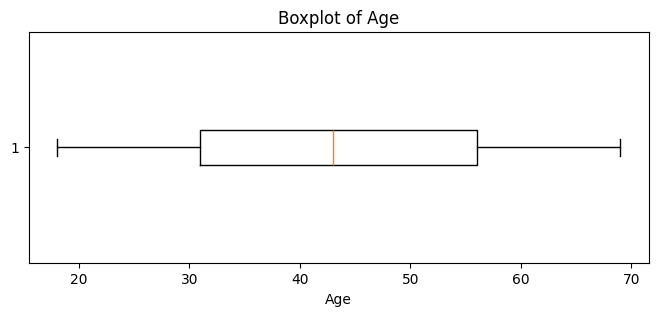

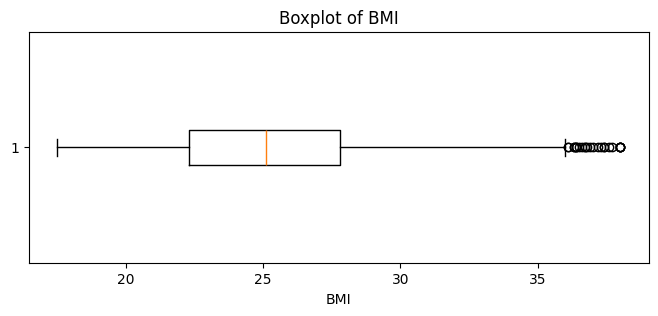

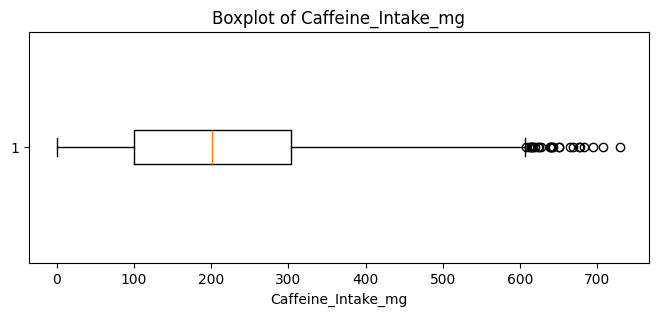

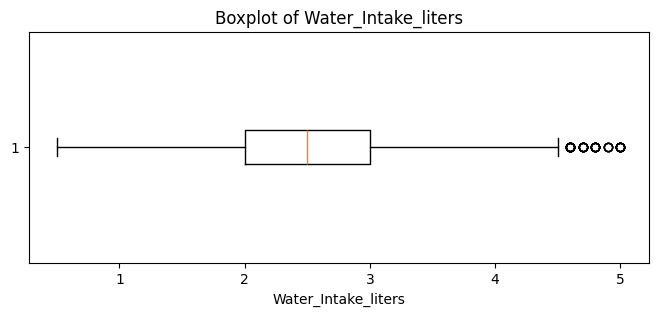

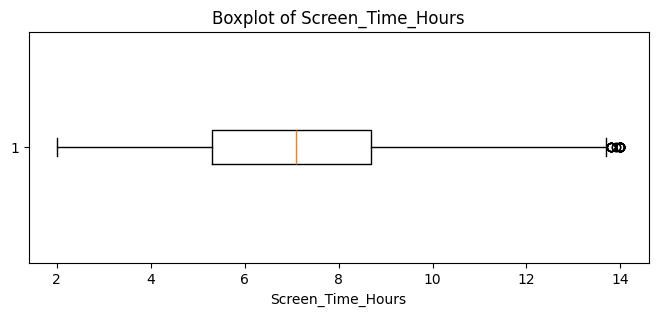

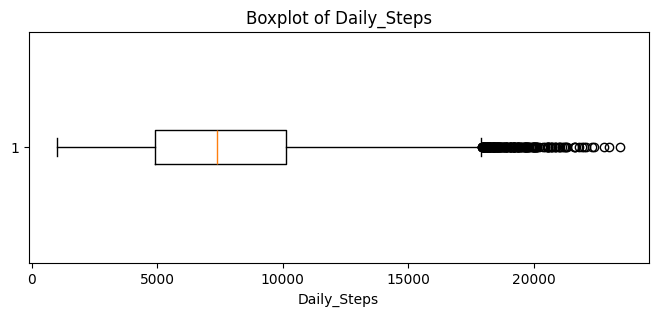

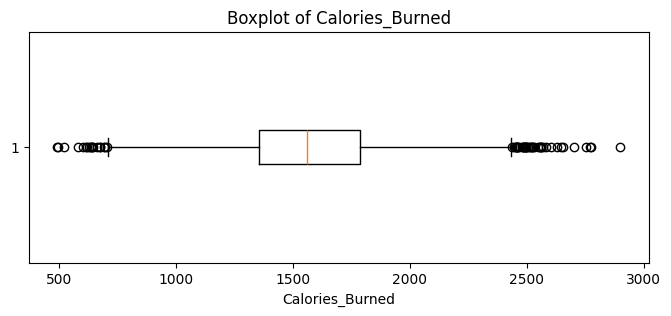

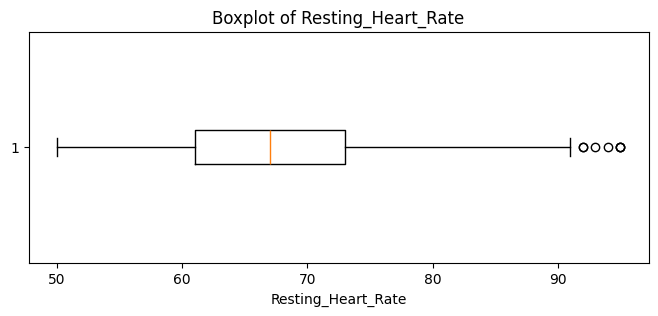

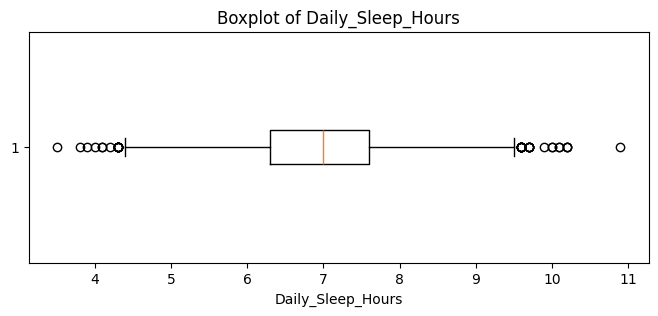

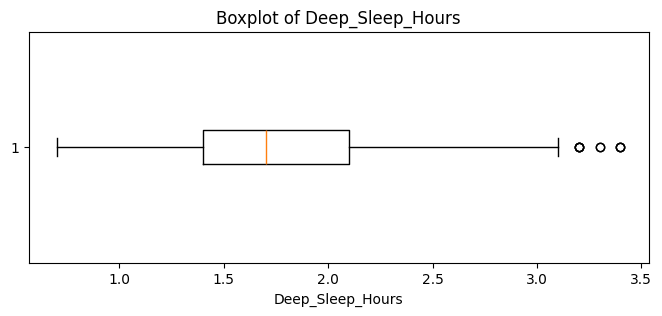

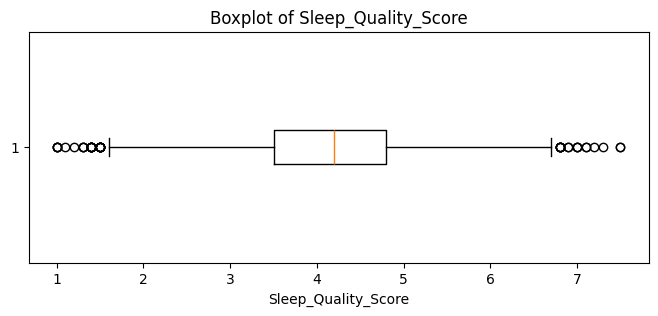

In [8]:
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    plt.figure(figsize=(8, 3))
    plt.boxplot(df[column].dropna(), vert=False)
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

#**Boxplot Analysis**

####The boxplots show that most numerical attributes contain outliers, while Age has no detected outliers. Daily_Steps has the highest number of outliers, with 182 values identified using the IQR method. Other attributes, such as BMI, Caffeine_Intake_mg, Water_Intake_liters, Screen_Time_Hours, Calories_Burned, Resting_Heart_Rate, Daily_Sleep_Hours, Deep_Sleep_Hours, and Sleep_Quality_Score also contain outliers. These results indicate that the outliers should be considered during the preprocessing stage before applying the data mining techniques.